**Introduction**

In this notebook, we'll be implementing Pearl's framework for Causal Inference using Bayesian Networks.

We'll not go into details of how Bayesian Networks work here - since this is a beginner's course, but this notebook will show clearly how we can apply the causal framework

**Installing libraries and importing the sample dataset**

In [ ]:
import warnings  # Import warnings module to control warning messages
warnings.filterwarnings('ignore')  # Suppress all warning messages during execution

In [ ]:
!pip install bnlearn==0.7.3  # Install bnlearn library for Bayesian network learning
!pip install numpy==1.19.5  # Install specific NumPy version for compatibility
!pip install pandas==1.3.5  # Install specific Pandas version for compatibility
!pip install matplotlib==3.3.4  # Install specific Matplotlib version for plotting

In [ ]:

import bnlearn as bn  # Import bnlearn for Bayesian network and causal inference

In [ ]:


df = bn.import_example('sprinkler')  # Load built-in sprinkler dataset from bnlearn
df.head(5)  # Display first 5 rows of the DataFrame


[bnlearn] >Import dataset..


,Cloudy,Sprinkler,Rain,Wet_Grass
0,0,0,0,0
1,1,0,1,1
2,0,1,0,1
3,1,1,1,1
4,1,1,1,1


### **What we want to estimate**

---



What is the effect of Sprinkler in making the Grass Wet?

*   Treatment: Sprinkler
*   Outcome: Wet Grass

## **Step 1: Defining our Causal DAG based on what we know of the variables**

In [ ]:
#Here we add all the relationships we think exist amogst our variables.
#The variable on the left is the one from which the arrow originates

edges = [('Sprinkler', 'Wet_Grass'),  # Define causal edges (directed relationships) between variables
         ('Rain', 'Wet_Grass'),  # Edge: Rain directly causes Wet Grass
         ('Cloudy', 'Sprinkler'),  # Edge: Cloudy weather affects whether Sprinkler is on
         ('Cloudy', 'Rain'),]  # Edge: Cloudy weather causes Rain

[bnlearn] >bayes DAG created.
[bnlearn]> Set node properties.
[bnlearn]> Set edge properties.
[bnlearn] >Plot based on Bayesian model


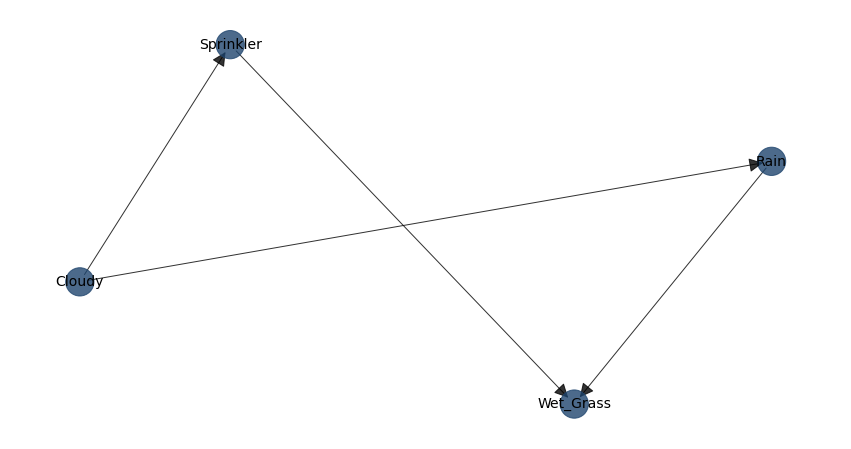

{'G': <networkx.classes.digraph.DiGraph at 0x7f7cca4daa10>,
 'edge_properties': {('Cloudy', 'Rain'): {'color': '#000000', 'weight': 1},
  ('Cloudy', 'Sprinkler'): {'color': '#000000', 'weight': 1},
  ('Rain', 'Wet_Grass'): {'color': '#000000', 'weight': 1},
  ('Sprinkler', 'Wet_Grass'): {'color': '#000000', 'weight': 1}},
 'node_properties': {'Cloudy': {'node_color': '#1f456e', 'node_size': 800},
  'Rain': {'node_color': '#1f456e', 'node_size': 800},
  'Sprinkler': {'node_color': '#1f456e', 'node_size': 800},
  'Wet_Grass': {'node_color': '#1f456e', 'node_size': 800}},
 'pos': {'Cloudy': array([-0.85468922, -0.32513885]),
  'Rain': array([0.91473536, 0.34037993]),
  'Sprinkler': array([-0.47008354,  0.98475892]),
  'Wet_Grass': array([ 0.4100374, -1.       ])}}

In [ ]:
#This function creates our DAG
DAG = bn.make_DAG(edges)  # Build Directed Acyclic Graph (DAG) from defined edges
#This function plots the DAG for visualization
bn.plot(DAG)  # Visualize the causal DAG as a network graph

## **Step 2: Fitting our model**

In [ ]:
## This part of the code fits a model that will gives us the probability distributions in the DAG
model = bn.parameter_learning.fit(DAG, df, methodtype='maximumlikelihood')  # Fit Bayesian network parameters using Maximum Likelihood Estimation


[bnlearn] >Parameter learning> Computing parameters using [maximumlikelihood]
[bnlearn] >CPD of Sprinkler:
+--------------+--------------------+------------+
| Cloudy       | Cloudy(0)          | Cloudy(1)  |
+--------------+--------------------+------------+
| Sprinkler(0) | 0.4610655737704918 | 0.91015625 |
+--------------+--------------------+------------+
| Sprinkler(1) | 0.5389344262295082 | 0.08984375 |
+--------------+--------------------+------------+
[bnlearn] >CPD of Wet_Grass:
+--------------+--------------+-----+----------------------+
| Rain         | Rain(0)      | ... | Rain(1)              |
+--------------+--------------+-----+----------------------+
| Sprinkler    | Sprinkler(0) | ... | Sprinkler(1)         |
+--------------+--------------+-----+----------------------+
| Wet_Grass(0) | 1.0          | ... | 0.023529411764705882 |
+--------------+--------------+-----+----------------------+
| Wet_Grass(1) | 0.0          | ... | 0.9764705882352941   |
+--------------+---

## **Step 3: Inferring causality using Pearl's Framework**

The confounding variable in this case is 'Cloudy' (affects Sprinkler and

affets Wet_Grass through rain)

**expected_wetgrass_when_sprinkler:**

P(wet_grass = 1 | do(sprinkler = 1) = P(cloudy = 0)*P(wet_grass = 1| sprinkler
= 1, cloudy = 0) + P(cloudy = 1)*P(wet_grass = 1| sprinkler = 1, cloudy = 1)

**expected_wetgrass_when_not_sprinkler:**

P(wet_grass = 1 | do(sprinkler = 0) = P(cloudy = 0)*P(wet_grass = 1| sprinkler
= 0, cloudy = 0) + P(cloudy = 1)*P(wet_grass = 1| sprinkler = 0, cloudy = 1)



**ATE:** expected_wetgrass_when_sprinkler - expected_wetgrass_when_not_sprinkler

In [ ]:
## Getting conditional probabilities again

bn.print_CPD(model)  # Print Conditional Probability Distributions (CPDs) for all nodes

##Getting the cloudy probabilities:

prob_cloudy =0.512  # Store prior probability of Cloudy = 1 (from CPD table)
prob_not_cloudy = 0.488  # Store prior probability of Cloudy = 0



CPD of Sprinkler:
+--------------+--------------------+------------+
| Cloudy       | Cloudy(0)          | Cloudy(1)  |
+--------------+--------------------+------------+
| Sprinkler(0) | 0.4610655737704918 | 0.91015625 |
+--------------+--------------------+------------+
| Sprinkler(1) | 0.5389344262295082 | 0.08984375 |
+--------------+--------------------+------------+
CPD of Wet_Grass:
+--------------+--------------+-----+----------------------+
| Rain         | Rain(0)      | ... | Rain(1)              |
+--------------+--------------+-----+----------------------+
| Sprinkler    | Sprinkler(0) | ... | Sprinkler(1)         |
+--------------+--------------+-----+----------------------+
| Wet_Grass(0) | 1.0          | ... | 0.023529411764705882 |
+--------------+--------------+-----+----------------------+
| Wet_Grass(1) | 0.0          | ... | 0.9764705882352941   |
+--------------+--------------+-----+----------------------+
CPD of Rain:
+---------+---------------------+------------

In [ ]:
#Probability of wet grass without sprinkler:

'What is the probability of WetGrass, given that sprinkler is turned off, and it is cloudy'
q1 = bn.inference.fit(model, variables=['Wet_Grass'], evidence={'Sprinkler':0,'Cloudy':1})  # Query: P(Wet_Grass | Sprinkler=OFF, Cloudy=YES) using belief propagation
q1.df  # Display probability table for the query result


[bnlearn] >Variable Elimination..


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

+----+-------------+----------+
|    |   Wet_Grass |        p |
+====+=============+==========+
|  0 |           0 | 0.271434 |
+----+-------------+----------+
|  1 |           1 | 0.728566 |
+----+-------------+----------+


,Wet_Grass,p
0,0,0.271434
1,1,0.728566


In [ ]:

#selecting only the variable that matters to us

q1.df.iloc[1,1]  # Extract P(Wet_Grass=1 | Sprinkler=0, Cloudy=1) value

0.7285655886627906

In [ ]:
p_grass_cloudy_no_sprinkler = q1.df.iloc[1,1]  # Save P(Wet_Grass=1 | Sprinkler=OFF, Cloudy=YES) for ATE calculation

In [ ]:
## Doing the same thing for when it is not cloudy:

'What is the probability of WetGrass, given that sprinkler is turned off, and it is NOT cloudy'
q2 = bn.inference.fit(model, variables=['Wet_Grass'], evidence={'Sprinkler':0,'Cloudy':0})  # Query: P(Wet_Grass | Sprinkler=OFF, Cloudy=NO) using belief propagation
q2.df  # Display probability table for the query result
p_grass_not_cloudy_no_sprinkler = q2.df.iloc[1,1]  # Save P(Wet_Grass=1 | Sprinkler=OFF, Cloudy=NO) for ATE calculation

[bnlearn] >Variable Elimination..


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

+----+-------------+----------+
|    |   Wet_Grass |        p |
+====+=============+==========+
|  0 |           0 | 0.829327 |
+----+-------------+----------+
|  1 |           1 | 0.170673 |
+----+-------------+----------+


In [ ]:
##Calculating the probability of wet grass without sprinkler:

prob_wet_no_sprinkler = prob_cloudy*p_grass_cloudy_no_sprinkler + prob_not_cloudy*p_grass_not_cloudy_no_sprinkler  # Compute P(Wet_Grass=1 | do(Sprinkler=0)) via backdoor adjustment formula

In [ ]:
prob_wet_no_sprinkler  # Display marginalised P(Wet_Grass=1) when sprinkler is OFF

0.45631395348837206

In [ ]:
## Calculating the probability of wet grass when sprinkler is on:

# Calculating the probability of Wet grass, without sprinkler:
'What is the probability of WetGrass, given that sprinkler is turned on, and it is cloudy'
q1 = bn.inference.fit(model, variables=['Wet_Grass'], evidence={'Sprinkler':1,'Cloudy':1})  # Query: P(Wet_Grass | Sprinkler=ON, Cloudy=YES) using belief propagation
q1.df  # Display probability table for the query result
p_grass_cloudy_sprinkler = q1.df.iloc[1,1]  # Save P(Wet_Grass=1 | Sprinkler=ON, Cloudy=YES) for ATE calculation

'What is the probability of WetGrass, given that sprinkler is turned on, and it is NOT cloudy'
q2 = bn.inference.fit(model, variables=['Wet_Grass'], evidence={'Sprinkler':1,'Cloudy':0})  # Query: P(Wet_Grass | Sprinkler=ON, Cloudy=NO) using belief propagation
q2.df  # Display probability table for the query result
p_grass_not_cloudy_sprinkler = q2.df.iloc[1,1]  # Save P(Wet_Grass=1 | Sprinkler=ON, Cloudy=NO) for ATE calculation

prob_wet_sprinkler = prob_cloudy*p_grass_cloudy_sprinkler + prob_not_cloudy*p_grass_not_cloudy_sprinkler  # Compute P(Wet_Grass=1 | do(Sprinkler=1)) via backdoor adjustment formula

prob_wet_sprinkler  # Display marginalised P(Wet_Grass=1) when sprinkler is ON

[bnlearn] >Variable Elimination..


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

+----+-------------+-----------+
|    |   Wet_Grass |         p |
+====+=============+===========+
|  0 |           0 | 0.0471184 |
+----+-------------+-----------+
|  1 |           1 | 0.952882  |
+----+-------------+-----------+
[bnlearn] >Variable Elimination..


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

+----+-------------+----------+
|    |   Wet_Grass |        p |
+====+=============+==========+
|  0 |           0 | 0.130685 |
+----+-------------+----------+
|  1 |           1 | 0.869315 |
+----+-------------+----------+


0.9121011029411764

In [ ]:
# Calculating the ATE:

ate = prob_wet_sprinkler - prob_wet_no_sprinkler  # Compute Average Treatment Effect: ATE = P(Y|do(T=1)) - P(Y|do(T=0))

ate  # Display the final ATE value (causal effect of Sprinkler on Wet Grass)

0.45578714945280435